In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import joblib

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix,
    classification_report
)

In [ ]:
TOKEN_PATH = (
    "/content/drive/MyDrive/FP_AI_2026/models/tfidf.pkl"
)

MODEL_PATH = (
    "/content/drive/MyDrive/FP_AI_2026/models/svm.pkl"
)

vectorizer = joblib.load(
    TOKEN_PATH
)

svm_model = joblib.load(
    MODEL_PATH
)

print("TF-IDF Loaded")
print("SVM Loaded")

TF-IDF Loaded
SVM Loaded


In [ ]:
TEST_PATH = (
    "/content/drive/MyDrive/FP_AI_2026/data/test.csv"
)

test_df = pd.read_csv(
    TEST_PATH
)

print(
    test_df.shape
)

test_df.head()

(100, 2)


,Sample_Code,Label
0,#include <iostream>\n#include <vector>\n\nusin...,1
1,import Java.util.Scanner;\n\npublic class Main...,0
2,public class BinarySearchTree {\n\n // Root...,0
3,#include <iostream>\n#include <cmath>\n\ndoubl...,1
4,import Java.util.Scanner;\n\npublic class Plus...,1


In [ ]:
X_test = test_df[
    "Sample_Code"
]

y_test = test_df[
    "Label"
]

In [ ]:
X_test_tfidf = vectorizer.transform(
    X_test
)

print(
    X_test_tfidf.shape
)

(100, 5000)


In [ ]:
preds = svm_model.predict(
    X_test_tfidf
)

probs = svm_model.predict_proba(
    X_test_tfidf
)[:,1]

In [ ]:
print(
    classification_report(
        y_test,
        preds,
        target_names=[
            "Human",
            "AI"
        ]
    )
)

              precision    recall  f1-score   support

       Human       0.92      0.92      0.92        50
          AI       0.92      0.92      0.92        50

    accuracy                           0.92       100
   macro avg       0.92      0.92      0.92       100
weighted avg       0.92      0.92      0.92       100



In [ ]:
error_df = test_df.copy()

error_df["Prediction"] = preds

error_df["Probability_AI"] = probs

error_df["Correct"] = (
    error_df["Label"]
    ==
    error_df["Prediction"]
)

error_df.head()

,Sample_Code,Label,Prediction,Probability_AI,Correct
0,#include <iostream>\n#include <vector>\n\nusin...,1,1,0.991894,True
1,import Java.util.Scanner;\n\npublic class Main...,0,0,0.000614,True
2,public class BinarySearchTree {\n\n // Root...,0,1,0.872538,False
3,#include <iostream>\n#include <cmath>\n\ndoubl...,1,1,0.999997,True
4,import Java.util.Scanner;\n\npublic class Plus...,1,1,0.990590,True


In [ ]:
print(
    "Total Data:",
    len(error_df)
)

print(
    "Correct:",
    error_df["Correct"].sum()
)

print(
    "Wrong:",
    (~error_df["Correct"]).sum()
)

Total Data: 100
Correct: 92
Wrong: 8


In [ ]:
fp_df = error_df[
    (error_df["Label"] == 0)
    &
    (error_df["Prediction"] == 1)
]

print(
    "False Positive:",
    len(fp_df)
)

fp_df.head()

False Positive: 4


,Sample_Code,Label,Prediction,Probability_AI,Correct
2,public class BinarySearchTree {\n\n // Root...,0,1,0.872538,False
65,# Python program for implementation of Quick S...,0,1,0.972152,False
75,//****************************************...,0,1,0.553966,False
90,// Source : https://oj.leetcode.com/problems/m...,0,1,0.940132,False


In [ ]:
fn_df = error_df[
    (error_df["Label"] == 1)
    &
    (error_df["Prediction"] == 0)
]

print(
    "False Negative:",
    len(fn_df)
)

fn_df.head()

False Negative: 4


,Sample_Code,Label,Prediction,Probability_AI,Correct
30,#include <iostream>\n#include <vector>\n#inclu...,1,0,0.235232,False
46,import Java.util.concurrent.ConcurrentLinkedDe...,1,0,0.090900,False
66,public class MaxNumber {\n public static void...,1,0,0.364447,False
83,#include <stdio.h>\n\nint main() {\n int i = ...,1,0,0.007788,False


In [ ]:
cm = confusion_matrix(
    y_test,
    preds
)

cm

array([[46,  4],
       [ 4, 46]])

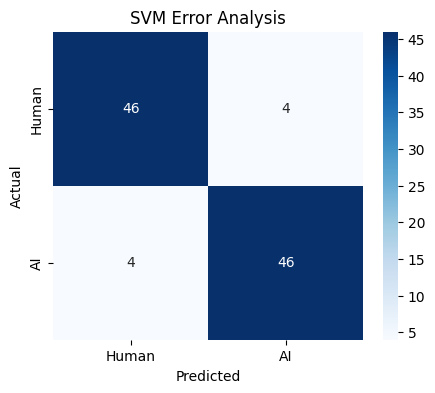

In [ ]:
plt.figure(
    figsize=(5,4)
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Human",
        "AI"
    ],
    yticklabels=[
        "Human",
        "AI"
    ]
)

plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)

plt.title(
    "SVM Error Analysis"
)

plt.show()

In [ ]:
for idx,row in fp_df.iterrows():

    print("="*120)

    print(
        f"INDEX : {idx}"
    )

    print(
        f"TRUE LABEL : {row['Label']}"
    )

    print(
        f"PREDICTION : {row['Prediction']}"
    )

    print(
        f"AI PROBABILITY : {row['Probability_AI']:.4f}"
    )

    print("\nCODE:\n")

    print(
        row["Sample_Code"]
    )

INDEX : 2
TRUE LABEL : 0
PREDICTION : 1
AI PROBABILITY : 0.8725

CODE:

public class BinarySearchTree {

    // Root of BST
    BstNode root;

    BinarySearchTree() {
        root = null;
    }

    void Insert(int data) {
        root = Insert(root, data);
    }

    BstNode Insert(BstNode root, int data) {

        if (root == null) {
            root = new BstNode(data);
        } else if (data < root.data)
            root.Left = Insert(root.Left, data);
        else if (data > root.data)
            root.Right = Insert(root.Right, data);

        return root;
    }

    void InOrder() {
        InOrder(root);
    }

    void InOrder(BstNode root) {
        if (root != null) {
            InOrder(root.Left);
            System.out.print(root.data + " ");
            InOrder(root.Right);
        }
    }

    void PreOrder() {
        PreOrder(root);
    }

    void PreOrder(BstNode root) {
        if (root == null)
            return;
        System.out.print(root.data + " ");
    

In [ ]:
for idx,row in fn_df.iterrows():

    print("="*120)

    print(
        f"INDEX : {idx}"
    )

    print(
        f"TRUE LABEL : {row['Label']}"
    )

    print(
        f"PREDICTION : {row['Prediction']}"
    )

    print(
        f"AI PROBABILITY : {row['Probability_AI']:.4f}"
    )

    print("\nCODE:\n")

    print(
        row["Sample_Code"]
    )

INDEX : 30
TRUE LABEL : 1
PREDICTION : 0
AI PROBABILITY : 0.2352

CODE:

#include <iostream>
#include <vector>
#include <algorithm>

using namespace std;

// Structure to represent an edge
struct Edge {
    int src, dest, weight;
};

// Disjoint Set Union (Union-Find) class
class DSU {
    vector<int> parent, rank;
public:
    DSU(int n) : parent(n), rank(n, 0) {
        for (int i = 0; i < n; i++) parent[i] = i;
    }

    int find(int i) {
        if (parent[i] == i) return i;
        return parent[i] = find(parent[i]); // Path compression
    }

    void unite(int i, int j) {
        int rootI = find(i);
        int rootJ = find(j);
        if (rootI != rootJ) {
            if (rank[rootI] < rank[rootJ]) parent[rootI] = rootJ;
            else if (rank[rootI] > rank[rootJ]) parent[rootJ] = rootI;
            else {
                parent[rootJ] = rootI;
                rank[rootI]++;
            }
        }
    }
};

// Custom comparator to sort edges by weight
bool compareEdges(Edg

In [ ]:
summary = pd.DataFrame({

    "Model":[
        "SVM"
    ],

    "False_Positive":[
        len(fp_df)
    ],

    "False_Negative":[
        len(fn_df)
    ],

    "Total_Error":[
        len(fp_df) + len(fn_df)
    ]
})

summary

,Model,False_Positive,False_Negative,Total_Error
0,SVM,4,4,8


In [ ]:
SAVE_DIR = (
    "/content/drive/MyDrive/FP_AI_2026/compare/"
)

fp_df.to_csv(
    SAVE_DIR + "svm_false_positive.csv",
    index=False
)

fn_df.to_csv(
    SAVE_DIR + "svm_false_negative.csv",
    index=False
)

summary.to_csv(
    SAVE_DIR + "svm_error_summary.csv",
    index=False
)

print(
    "Saved!"
)

Saved!
